# **1. Perkenalan Dataset**

## Heart Disease UCI Dataset

Dataset yang digunakan adalah **Heart Disease UCI** yang tersedia di Kaggle. Dataset ini berisi informasi medis pasien yang digunakan untuk memprediksi apakah seseorang mengidap penyakit jantung atau tidak.

### Informasi Dataset:
- **Sumber**: [Kaggle - Heart Disease UCI](https://www.kaggle.com/datasets/cherngs/heart-disease-cleveland-uci)
- **Jumlah Fitur**: 13 fitur input + 1 target
- **Target**: `condition` — 0 (tidak sakit jantung), 1 (sakit jantung)
- **Task**: Binary Classification

### Deskripsi Fitur:
| Fitur | Deskripsi |
|---|---|
| age | Usia pasien |
| sex | Jenis kelamin (1=laki-laki, 0=perempuan) |
| cp | Tipe nyeri dada (0-3) |
| trestbps | Tekanan darah saat istirahat |
| chol | Kadar kolesterol serum |
| fbs | Gula darah puasa > 120 mg/dl (1=ya, 0=tidak) |
| restecg | Hasil EKG saat istirahat (0-2) |
| thalach | Denyut jantung maksimum |
| exang | Angina akibat olahraga (1=ya, 0=tidak) |
| oldpeak | Depresi ST akibat olahraga |
| slope | Kemiringan segmen ST puncak |
| ca | Jumlah pembuluh utama (0-3) |
| thal | Thalassemia (0-3) |
| condition | Target: 0=tidak sakit, 1=sakit jantung |

# **2. Import Library**

Mengimpor pustaka Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
# === Data Manipulation ===
import pandas as pd
import numpy as np

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns

# === Preprocessing ===
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# === Machine Learning ===
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score)

# === Utility ===
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Semua library berhasil diimport!')
print(f'Pandas version  : {pd.__version__}')
print(f'NumPy version   : {np.__version__}')

Semua library berhasil diimport!
Pandas version  : 2.2.2
NumPy version   : 2.0.2


# **3. Memuat Dataset**

Dataset dimuat langsung dari Kaggle menggunakan `kaggle` API. Pastikan file `kaggle.json` sudah tersedia di environment.

In [2]:
# Install kaggle jika belum ada
!pip install kaggle -q

import os
os.makedirs('/root/.kaggle', exist_ok=True)

# Copy kaggle.json yang sudah diupload
!cp /content/kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
print("kaggle.json berhasil dipasang!")

# Download dataset
!kaggle datasets download -d cherngs/heart-disease-cleveland-uci -p ./heart_disease_raw --unzip
print('Dataset berhasil didownload!')

kaggle.json berhasil dipasang!
Dataset URL: https://www.kaggle.com/datasets/cherngs/heart-disease-cleveland-uci
License(s): reddit-api
100% 3.33k/3.33k [00:00<00:00, 6.25MB/s]

Dataset berhasil didownload!


In [5]:
# Memuat dataset ke DataFrame
df = pd.read_csv('/content/heart_disease_raw/heart_cleveland_upload.csv')

print('=' * 50)
print('INFORMASI DASAR DATASET')
print('=' * 50)
print(f'Jumlah baris    : {df.shape[0]}')
print(f'Jumlah kolom    : {df.shape[1]}')
print(f'Kolom target    : condition')
print()
print('5 baris pertama dataset:')
df.head()

INFORMASI DASAR DATASET
Jumlah baris    : 297
Jumlah kolom    : 14
Kolom target    : condition

5 baris pertama dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [6]:
# Simpan dataset raw
os.makedirs('/content/heart_disease_raw', exist_ok=True)
df.to_csv('/content/heart_disease_raw/heart_cleveland_upload.csv', index=False)
print('Dataset raw disimpan di content/heart_disease_raw/heart_cleveland_upload.csv')

Dataset raw disimpan di content/heart_disease_raw/heart_cleveland_upload.csv


# **4. Exploratory Data Analysis (EDA)**

Melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset sebelum preprocessing.

In [7]:
# --- 4.1 Informasi Tipe Data dan Missing Values ---
print('=' * 50)
print('INFO TIPE DATA')
print('=' * 50)
df.info()

INFO TIPE DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [8]:
# --- 4.2 Statistik Deskriptif ---
print('=' * 50)
print('STATISTIK DESKRIPTIF')
print('=' * 50)
df.describe().T

STATISTIK DESKRIPTIF


,count,mean,std,min,25%,50%,75%,max
age,297.0,54.542088,9.049736,29.0,48.0,56.0,61.0,77.0
sex,297.0,0.676768,0.468500,0.0,0.0,1.0,1.0,1.0
cp,297.0,2.158249,0.964859,0.0,2.0,2.0,3.0,3.0
trestbps,297.0,131.693603,17.762806,94.0,120.0,130.0,140.0,200.0
chol,297.0,247.350168,51.997583,126.0,211.0,243.0,276.0,564.0
fbs,297.0,0.144781,0.352474,0.0,0.0,0.0,0.0,1.0
restecg,297.0,0.996633,0.994914,0.0,0.0,1.0,2.0,2.0
thalach,297.0,149.599327,22.941562,71.0,133.0,153.0,166.0,202.0
exang,297.0,0.326599,0.469761,0.0,0.0,0.0,1.0,1.0
oldpeak,297.0,1.055556,1.166123,0.0,0.0,0.8,1.6,6.2


In [10]:
# --- 4.3 Cek Missing Values ---
print('=' * 50)
print('MISSING VALUES')
print('=' * 50)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0] if missing.sum() > 0 else 'Tidak ada missing values!')

MISSING VALUES
Tidak ada missing values!


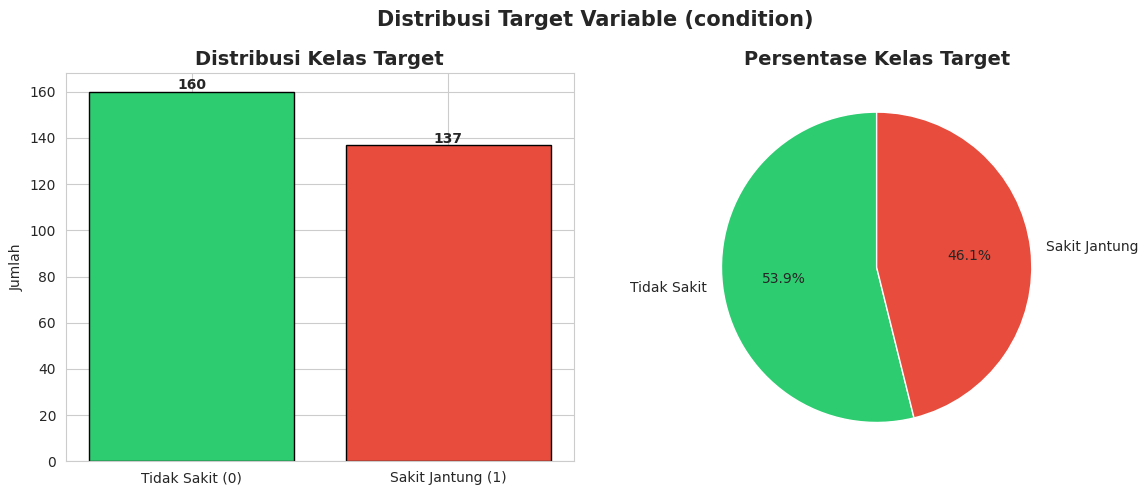


Distribusi:
condition
0    160
1    137
Name: count, dtype: int64


In [11]:
# --- 4.4 Distribusi Target ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
target_counts = df['condition'].value_counts()
axes[0].bar(['Tidak Sakit (0)', 'Sakit Jantung (1)'], target_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Distribusi Kelas Target', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['Tidak Sakit', 'Sakit Jantung'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Persentase Kelas Target', fontsize=14, fontweight='bold')

plt.suptitle('Distribusi Target Variable (condition)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'\nDistribusi:\n{target_counts}')

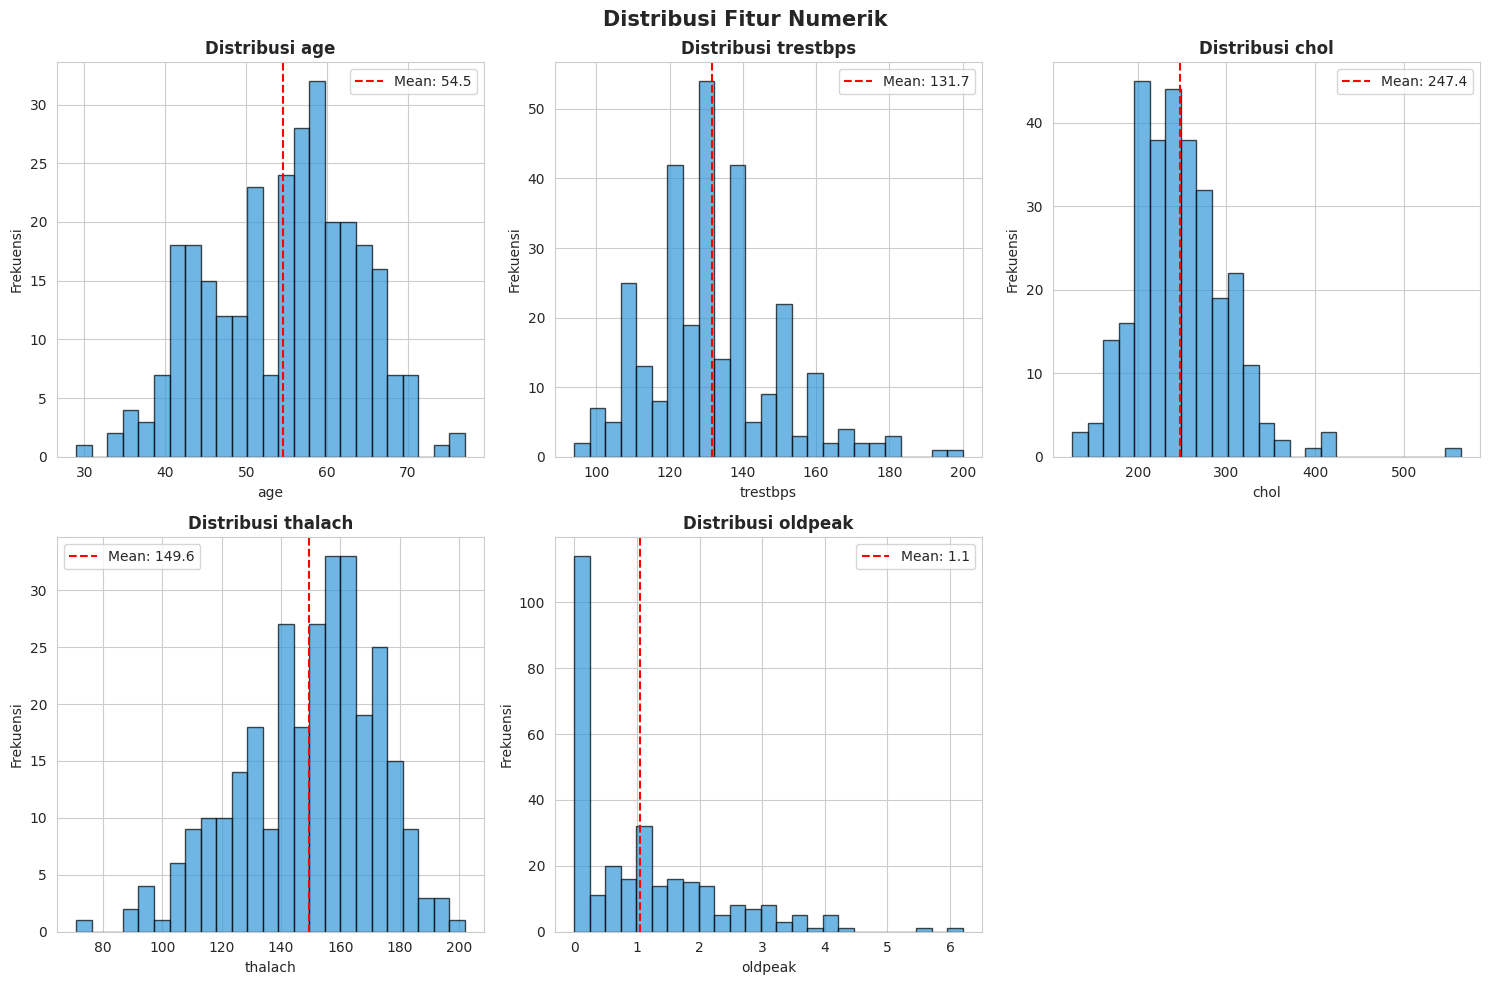

In [12]:
# --- 4.5 Distribusi Fitur Numerik ---
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=25, color='#3498db', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[i].legend()

axes[-1].axis('off')
plt.suptitle('Distribusi Fitur Numerik', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

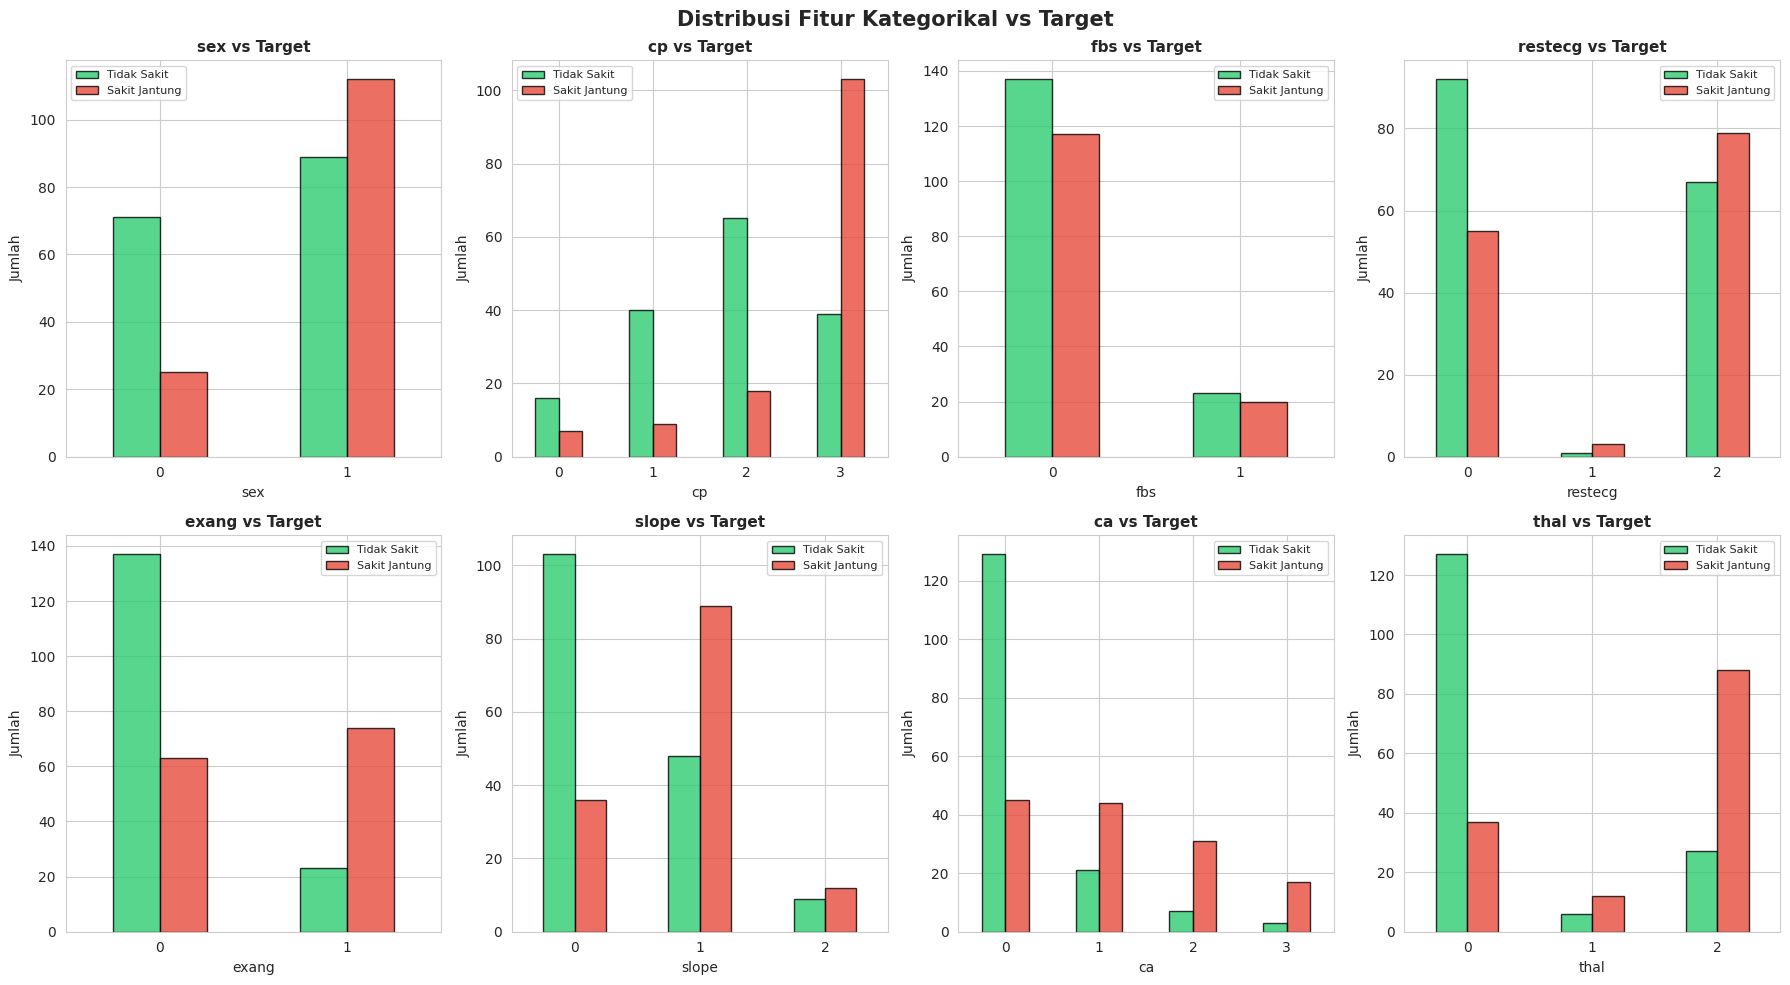

In [13]:
# --- 4.6 Distribusi Fitur Kategorikal ---
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = df.groupby([col, 'condition']).size().unstack(fill_value=0)
    counts.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
                edgecolor='black', alpha=0.8)
    axes[i].set_title(f'{col} vs Target', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(['Tidak Sakit', 'Sakit Jantung'], fontsize=8)

plt.suptitle('Distribusi Fitur Kategorikal vs Target', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

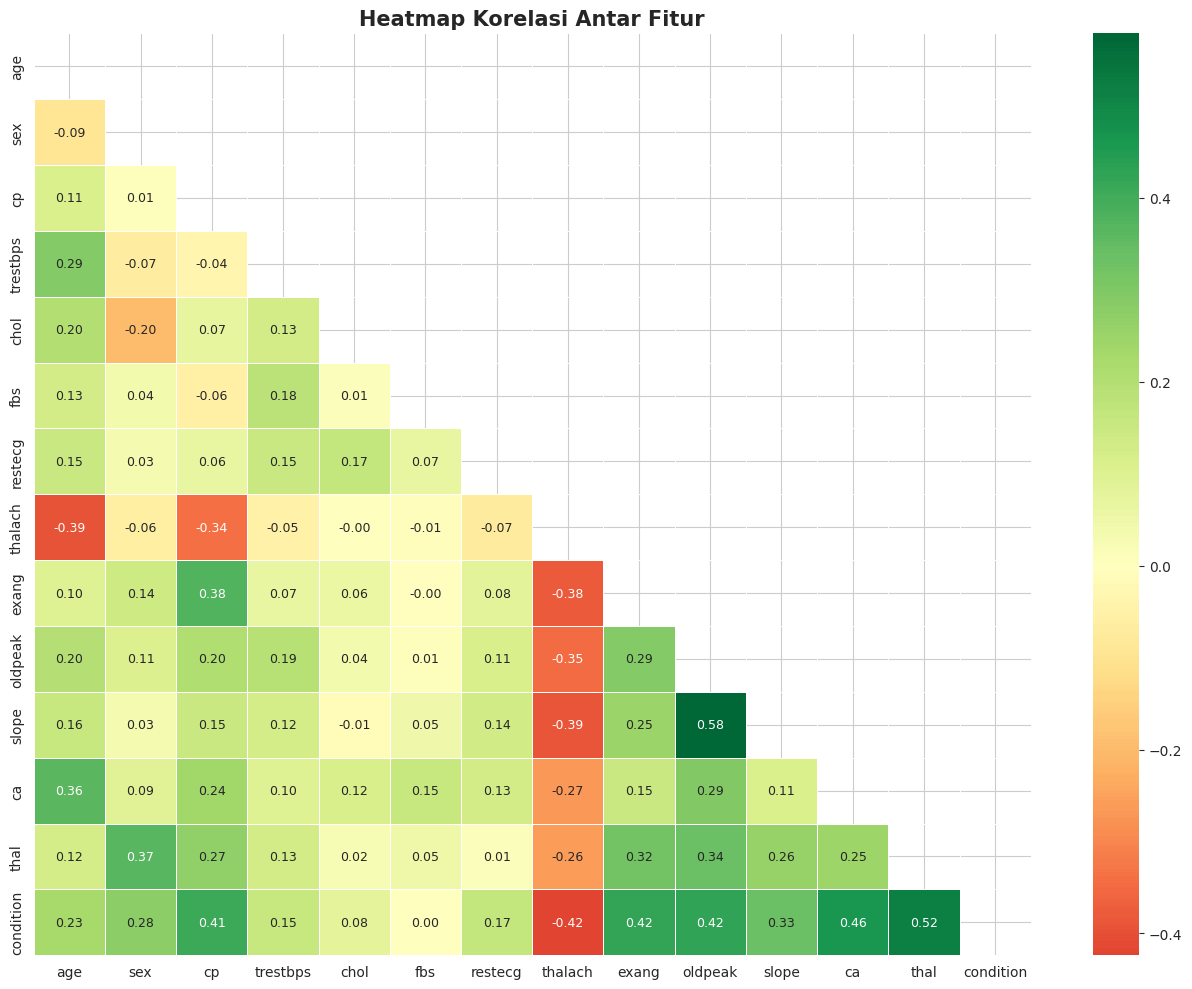


Korelasi fitur terhadap target (condition):
thal        0.520516
ca          0.463189
oldpeak     0.424052
exang       0.421355
cp          0.408945
slope       0.333049
sex         0.278467
age         0.227075
restecg     0.166343
trestbps    0.153490
chol        0.080285
fbs         0.003167
thalach    -0.423817
Name: condition, dtype: float64


In [14]:
# --- 4.7 Heatmap Korelasi ---
plt.figure(figsize=(13, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Korelasi terhadap target
print('\nKorelasi fitur terhadap target (condition):')
print(corr_matrix['condition'].drop('condition').sort_values(ascending=False))

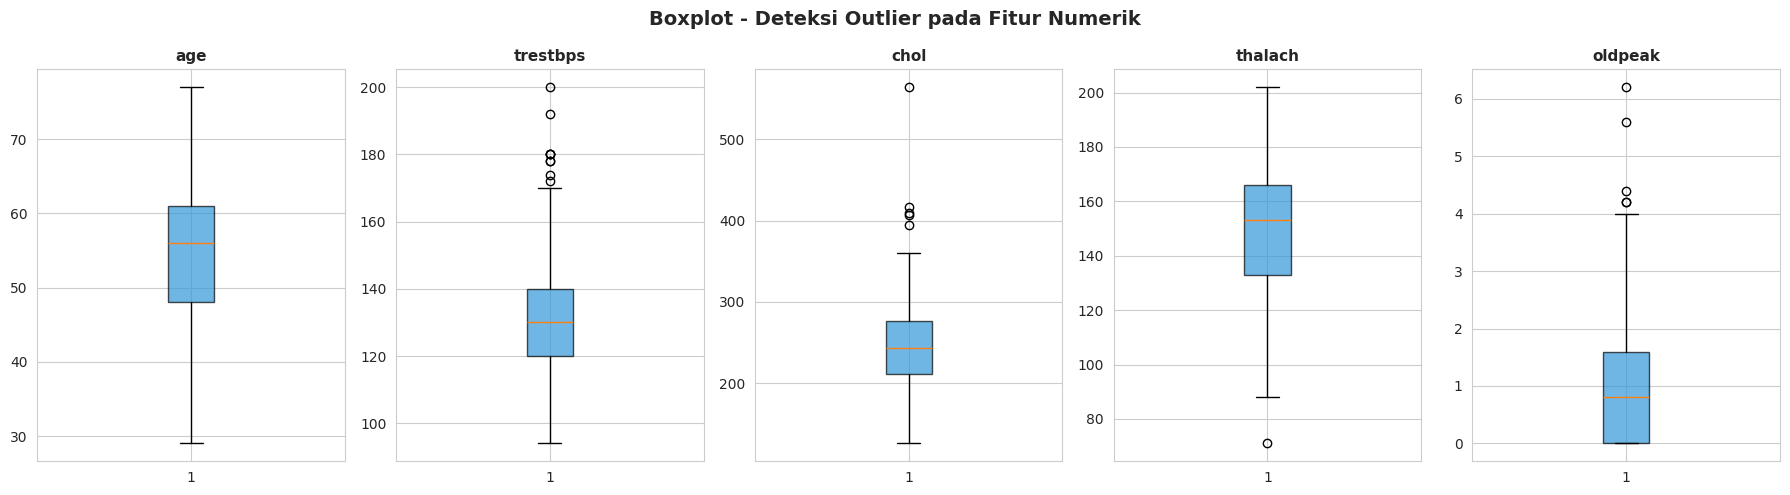

In [15]:
# --- 4.8 Boxplot Deteksi Outlier ---
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(18, 5))

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.7))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Boxplot - Deteksi Outlier pada Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

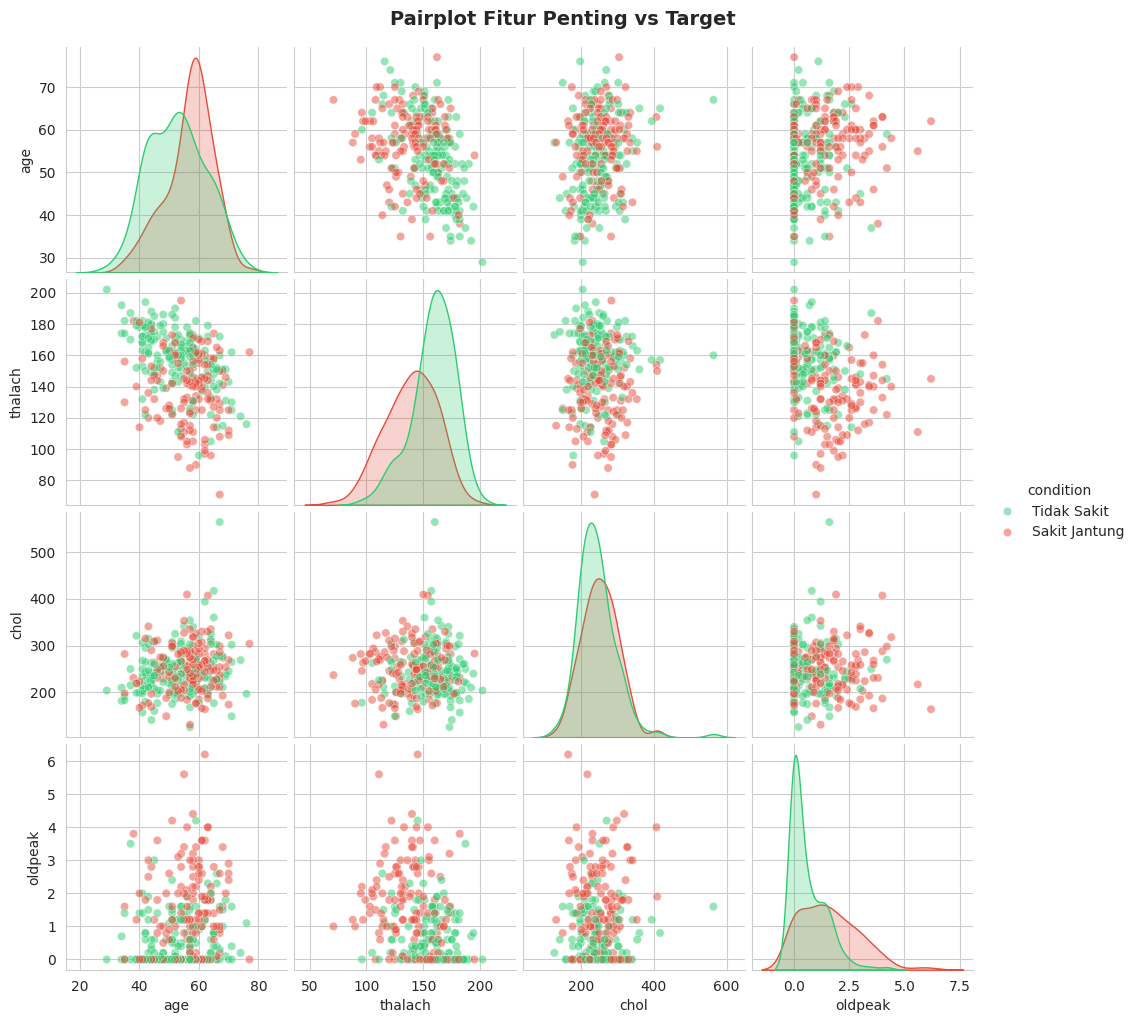

In [16]:
# --- 4.9 Pairplot fitur penting vs target ---
important_cols = ['age', 'thalach', 'chol', 'oldpeak', 'condition']
pair_df = df[important_cols].copy()
pair_df['condition'] = pair_df['condition'].map({0: 'Tidak Sakit', 1: 'Sakit Jantung'})

sns.pairplot(pair_df, hue='condition', palette={'Tidak Sakit': '#2ecc71', 'Sakit Jantung': '#e74c3c'},
             diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot Fitur Penting vs Target', y=1.02, fontsize=14, fontweight='bold')
plt.show()

### Ringkasan Temuan EDA

1. **Distribusi Target**: Dataset relatif seimbang (~54% tidak sakit, ~46% sakit jantung)
2. **Missing Values**: Tidak ada missing values pada dataset
3. **Korelasi Tertinggi dengan Target**:
   - `thalach` (denyut jantung maks) — korelasi negatif kuat
   - `cp` (tipe nyeri dada) — korelasi positif kuat
   - `exang` (angina akibat olahraga) — korelasi positif
   - `oldpeak` — korelasi positif
4. **Outlier**: Ditemukan pada `chol`, `trestbps`, dan `oldpeak`
5. **Fitur Kategorikal**: Beberapa fitur perlu encoding (cp, restecg, slope, thal)

# **5. Data Preprocessing**

Melakukan preprocessing data agar siap digunakan untuk pelatihan model machine learning.

In [17]:
# --- 5.1 Salin dataframe agar data asli tidak berubah ---
df_processed = df.copy()
print(f'Shape awal: {df_processed.shape}')
print(f'Kolom: {list(df_processed.columns)}')

Shape awal: (297, 14)
Kolom: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition']


In [19]:
# --- 5.2 Menangani Missing Values ---
print('=== Penanganan Missing Values ===')
print(f'Missing values sebelum: {df_processed.isnull().sum().sum()}')

# Fitur numerik: isi dengan median
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
for col in num_cols:
    if df_processed[col].isnull().sum() > 0:
        median_val = df_processed[col].median()
        df_processed[col].fillna(median_val, inplace=True)
        print(f'  → {col}: diisi dengan median ({median_val:.2f})')

# Fitur kategorikal: isi dengan modus
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in cat_cols:
    if df_processed[col].isnull().sum() > 0:
        mode_val = df_processed[col].mode()[0]
        df_processed[col].fillna(mode_val, inplace=True)
        print(f'  → {col}: diisi dengan modus ({mode_val})')

print(f'Missing values setelah: {df_processed.isnull().sum().sum()}')
print('Missing values berhasil ditangani!')

=== Penanganan Missing Values ===
Missing values sebelum: 0
Missing values setelah: 0
Missing values berhasil ditangani!


In [21]:
# --- 5.3 Menghapus Data Duplikat ---
print('=== Penghapusan Duplikat ===')
n_dup = df_processed.duplicated().sum()
print(f'Jumlah duplikat: {n_dup}')
df_processed.drop_duplicates(inplace=True)
df_processed.reset_index(drop=True, inplace=True)
print(f'Shape setelah hapus duplikat: {df_processed.shape}')
print('Duplikat berhasil dihapus!')

=== Penghapusan Duplikat ===
Jumlah duplikat: 0
Shape setelah hapus duplikat: (297, 14)
Duplikat berhasil dihapus!


In [22]:
# --- 5.4 Deteksi dan Penanganan Outlier (IQR Method) ---
print('=== Penanganan Outlier (IQR Method) ===')

def handle_outliers_iqr(df, col):
    """Clip outlier menggunakan batas IQR."""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    return n_outlier, lower, upper

for col in num_cols:
    n_out, lo, up = handle_outliers_iqr(df_processed, col)
    print(f'  {col}: {n_out} outlier di-clip ke [{lo:.2f}, {up:.2f}]')

print('Outlier berhasil ditangani!')

=== Penanganan Outlier (IQR Method) ===
  age: 0 outlier di-clip ke [28.50, 80.50]
  trestbps: 9 outlier di-clip ke [90.00, 170.00]
  chol: 5 outlier di-clip ke [113.50, 373.50]
  thalach: 1 outlier di-clip ke [83.50, 215.50]
  oldpeak: 5 outlier di-clip ke [-2.40, 4.00]
Outlier berhasil ditangani!


In [23]:
# --- 5.5 Encoding Fitur Kategorikal (One-Hot Encoding) ---
print('=== Encoding Fitur Kategorikal ===')
# Fitur multi-kelas: cp, restecg, slope, thal → One-Hot Encoding
ohe_cols = ['cp', 'restecg', 'slope', 'thal']

df_processed = pd.get_dummies(df_processed, columns=ohe_cols, drop_first=False, dtype=int)

print(f'Kolom setelah encoding: {list(df_processed.columns)}')
print(f'Shape setelah encoding: {df_processed.shape}')
print('Encoding berhasil!')

=== Encoding Fitur Kategorikal ===
Kolom setelah encoding: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'condition', 'cp_0', 'cp_1', 'cp_2', 'cp_3', 'restecg_0', 'restecg_1', 'restecg_2', 'slope_0', 'slope_1', 'slope_2', 'thal_0', 'thal_1', 'thal_2']
Shape setelah encoding: (297, 23)
Encoding berhasil!


In [24]:
# --- 5.6 Pemisahan Fitur dan Target ---
X = df_processed.drop('condition', axis=1)
y = df_processed['condition']

print(f'Fitur (X): {X.shape}')
print(f'Target (y): {y.shape}')
print(f'Distribusi target:\n{y.value_counts()}')

Fitur (X): (297, 22)
Target (y): (297,)
Distribusi target:
condition
0    160
1    137
Name: count, dtype: int64


In [25]:
# --- 5.7 Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test : {X_test.shape},  y_test : {y_test.shape}')
print(f'Distribusi y_train: {dict(y_train.value_counts())}')
print(f'Distribusi y_test : {dict(y_test.value_counts())}')

X_train: (237, 22), y_train: (237,)
X_test : (60, 22),  y_test : (60,)
Distribusi y_train: {0: np.int64(128), 1: np.int64(109)}
Distribusi y_test : {0: np.int64(32), 1: np.int64(28)}


In [26]:
# --- 5.8 Normalisasi / Standarisasi Fitur Numerik ---
print('=== Standarisasi Fitur Numerik ===')
scaler = StandardScaler()

# Hanya standarisasi kolom numerik yang ada
num_cols_available = [c for c in num_cols if c in X_train.columns]

X_train[num_cols_available] = scaler.fit_transform(X_train[num_cols_available])
X_test[num_cols_available]  = scaler.transform(X_test[num_cols_available])

print(f'Kolom yang distandarisasi: {num_cols_available}')
print('Standarisasi berhasil!')
X_train.describe().T[['mean', 'std']].head()

=== Standarisasi Fitur Numerik ===
Kolom yang distandarisasi: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Standarisasi berhasil!


,mean,std
age,-3.222926e-16,1.002116
sex,6.919831e-01,0.462651
trestbps,3.831909e-16,1.002116
chol,2.173601e-16,1.002116
fbs,1.434599e-01,0.351283


In [27]:
# --- 5.9 Simpan Dataset yang Sudah Diproses ---
os.makedirs('/content/heart_disease_preprocessing', exist_ok=True)

# Gabungkan kembali X_train + y_train untuk disimpan
train_processed = X_train.copy()
train_processed['condition'] = y_train.values

test_processed = X_test.copy()
test_processed['condition'] = y_test.values

train_processed.to_csv('/content/heart_disease_preprocessing/heart_train_preprocessed.csv', index=False)
test_processed.to_csv('/content/heart_disease_preprocessing/heart_test_preprocessed.csv', index=False)

print('Dataset yang sudah diproses disimpan:')
print('   → /content/heart_disease_preprocessing/heart_train_preprocessed.csv')
print('   → /content/heart_disease_preprocessing/heart_test_preprocessed.csv')
print(f'\nShape train: {train_processed.shape}')
print(f'Shape test : {test_processed.shape}')

Dataset yang sudah diproses disimpan:
   → /content/heart_disease_preprocessing/heart_train_preprocessed.csv
   → /content/heart_disease_preprocessing/heart_test_preprocessed.csv

Shape train: (237, 23)
Shape test : (60, 23)


### Ringkasan Tahapan Preprocessing

| Tahapan | Keterangan |
|---|---|
| Missing Values | Tidak ada missing values pada dataset ini |
| Duplikat | Dihapus jika ada |
| Outlier | Di-clip menggunakan batas IQR (1.5×IQR) |
| Encoding | One-Hot Encoding untuk fitur multi-kelas (cp, restecg, slope, thal) |
| Train-Test Split | 80% train, 20% test (stratified) |
| Standarisasi | StandardScaler pada fitur numerik kontinyu |

Dataset siap digunakan untuk pelatihan model!